# Support Vector Machine - Loan Status Classification

In [8]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [9]:
# Load data from CSV files (adjust paths if needed)
train_data = pd.read_csv('../../Datasets/train_v9rqX0R.csv')
test_data = pd.read_csv('../../Datasets/train_v9rqX0R.csv')  # Using same file for demo

print(f"Training set shape: {train_data.shape}")
print(f"Test set shape: {test_data.shape}")
print(f"\nFeatures: {train_data.columns.tolist()}")

Training set shape: (8523, 12)
Test set shape: (8523, 12)

Features: ['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']


In [10]:
train_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [11]:
# Identify target column and separate features
print("Data Info:")
train_data.info()
print("\nMissing Values:")
print(train_data.isnull().sum())

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB

Missing Values:
Item_Identifier                 0


In [12]:
# Separate features and target (assuming last column is target)
target_col = train_data.columns[-1]
X_train = train_data.iloc[:, :-1].copy()
X_test = test_data.iloc[:, :-1].copy()
y_train = train_data[target_col].copy()
y_test = test_data[target_col].copy()

# Handle missing values - fill with median for numeric columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
X_train[numeric_cols] = X_train[numeric_cols].fillna(X_train[numeric_cols].median())
X_test[numeric_cols] = X_test[numeric_cols].fillna(X_train[numeric_cols].median())

# Drop categorical columns with high cardinality for simplicity
cat_cols = X_train.select_dtypes(include=['object']).columns
X_train = X_train.drop(cat_cols, axis=1)
X_test = X_test.drop(cat_cols, axis=1)

print(f"Final feature shape: {X_train.shape}")
print(f"Target distribution:\n{y_train.value_counts()}")

Final feature shape: (8523, 4)
Target distribution:
Item_Outlet_Sales
958.7520     17
1342.2528    16
703.0848     15
1845.5976    15
1230.3984    14
             ..
3944.8650     1
515.9950      1
7182.6504     1
3608.6360     1
2778.3834     1
Name: count, Length: 3493, dtype: int64


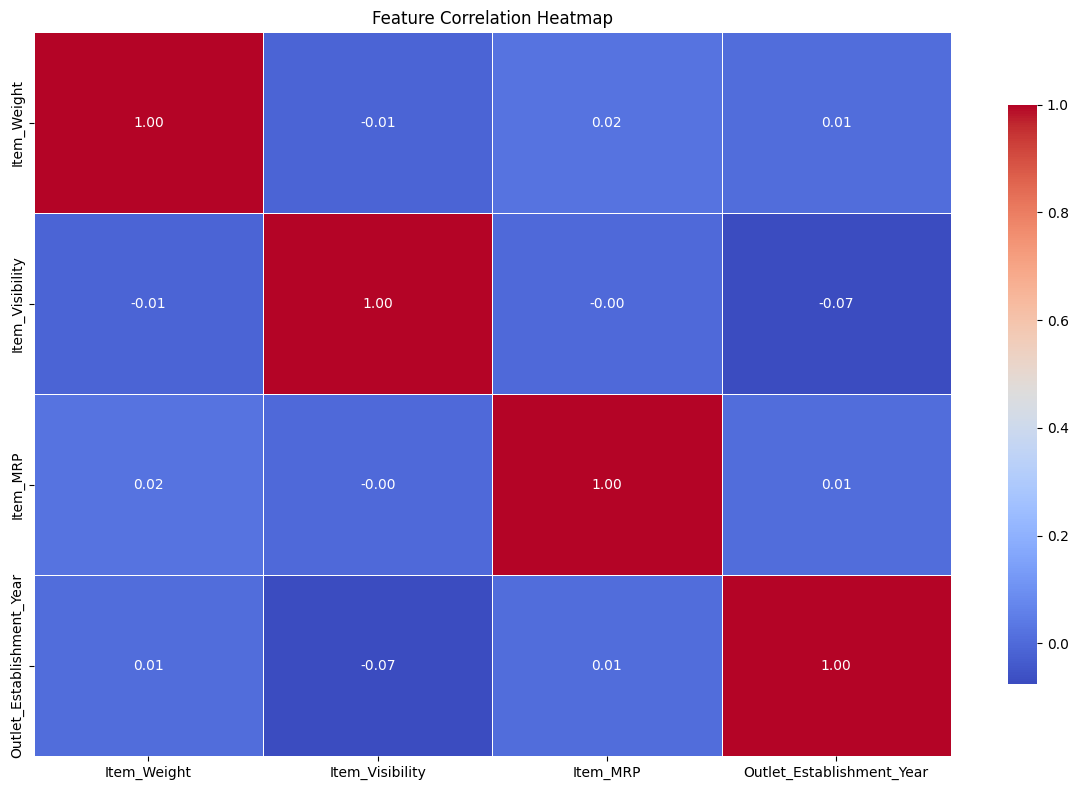

In [13]:
# Visualize feature correlations
plt.figure(figsize=(12, 8))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Model 1: SVM without Feature Engineering

### Step 1: Feature Scaling with RobustScaler

In [14]:
# Apply RobustScaler
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
	scaler.fit_transform(X_train),
	columns=X_train.columns,
	index=X_train.index
)
X_test_scaled = pd.DataFrame(
	scaler.transform(X_test),
	columns=X_test.columns,
	index=X_test.index
)

print("Feature scaling completed")
print(f"X_train_scaled mean: {X_train_scaled.mean().mean():.6f}")
print(f"X_train_scaled std: {X_train_scaled.std().mean():.6f}")

Feature scaling completed
X_train_scaled mean: 0.030422
X_train_scaled std: 0.641478


### Step 2: Hyperparameter Tuning with GridSearchCV

In [15]:
# Define parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid'],
}

print("Parameter grid defined")
print(f"Total combinations: {4 * 4 * 3} = 48")

Parameter grid defined
Total combinations: 48 = 48


In [17]:
# Perform GridSearchCV
print("Training Model 1 (SVM without Feature Engineering)...")

# SVC requires discrete class labels, so bin continuous target into classes
bin_edges = np.unique(np.quantile(y_train, q=np.linspace(0, 1, 6)))
bin_edges[0], bin_edges[-1] = -np.inf, np.inf

y_train = pd.cut(y_train, bins=bin_edges, labels=False, include_lowest=True).astype(int)
y_test = pd.cut(y_test, bins=bin_edges, labels=False, include_lowest=True).astype(int)

model1 = SVC(random_state=3453)
grid1 = GridSearchCV(estimator=model1, param_grid=param_grid, cv=5, n_jobs=-1)
grid1.fit(X_train_scaled, y_train)
print("Model 1 training completed!")

Training Model 1 (SVM without Feature Engineering)...
Model 1 training completed!


In [18]:
# Evaluate Model 1
best_model1 = grid1.best_estimator_
y_pred1 = best_model1.predict(X_test_scaled)

print("="*60)
print("MODEL 1 RESULTS (Without Feature Engineering)")
print("="*60)
print(f"\nBest Hyperparameters: {grid1.best_params_}")
print(f"Best CV Score: {grid1.best_score_:.4f}")
print(f"Test Set Accuracy: {accuracy_score(y_test, y_pred1):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred1))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred1))

MODEL 1 RESULTS (Without Feature Engineering)

Best Hyperparameters: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score: 0.4121
Test Set Accuracy: 0.4249

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.42      0.46      1707
           1       0.51      0.23      0.31      1706
           2       0.36      0.38      0.37      1701
           3       0.33      0.41      0.37      1707
           4       0.48      0.69      0.56      1702

    accuracy                           0.42      8523
   macro avg       0.44      0.42      0.41      8523
weighted avg       0.44      0.42      0.41      8523


Confusion Matrix:
[[ 724  241  258  211  273]
 [ 382  384  496  254  190]
 [ 161  117  639  526  258]
 [ 114   16  321  707  549]
 [  58    0   49  428 1167]]


## Model 2: SVM with Feature Engineering

In [19]:
def feature_engineering(data: pd.DataFrame) -> pd.DataFrame:
    """
    Apply feature engineering to create additional features.
    """
    data_fe = data.copy()
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    
    # Create polynomial features for first numeric column
    if len(numeric_cols) > 0:
        col1 = numeric_cols[0]
        data_fe[f'{col1}_squared'] = data_fe[col1] ** 2
        data_fe[f'{col1}_log'] = np.log(np.abs(data_fe[col1]) + 1)  # Avoid log(0)
    
    # Create interaction features between first two numeric columns
    if len(numeric_cols) > 1:
        col1, col2 = numeric_cols[0], numeric_cols[1]
        data_fe[f'{col1}_x_{col2}'] = data_fe[col1] * data_fe[col2]
        data_fe[f'{col1}_{col2}_ratio'] = data_fe[col1] / (np.abs(data_fe[col2]) + 1)
    
    return data_fe

# Apply feature engineering
X_train_fe = feature_engineering(X_train_scaled)
X_test_fe = feature_engineering(X_test_scaled)

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Features after engineering: {X_train_fe.shape[1]}")

Original features: 4
Features after engineering: 8


In [20]:
print("Training Model 2 (SVM with Feature Engineering)...")
model2 = SVC(random_state=3422)
grid2 = GridSearchCV(estimator=model2, param_grid=param_grid, cv=5, n_jobs=-1)
grid2.fit(X_train_fe, y_train)
print("Model 2 training completed!")

Training Model 2 (SVM with Feature Engineering)...
Model 2 training completed!


In [21]:
# Evaluate Model 2
best_model2 = grid2.best_estimator_
y_pred2 = best_model2.predict(X_test_fe)

print("="*60)
print("MODEL 2 RESULTS (With Feature Engineering)")
print("="*60)
print(f"\nBest Hyperparameters: {grid2.best_params_}")
print(f"Best CV Score: {grid2.best_score_:.4f}")
print(f"Test Set Accuracy: {accuracy_score(y_test, y_pred2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred2))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred2))

MODEL 2 RESULTS (With Feature Engineering)

Best Hyperparameters: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score: 0.4128
Test Set Accuracy: 0.4360

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.45      0.48      1707
           1       0.51      0.23      0.32      1706
           2       0.37      0.39      0.38      1701
           3       0.36      0.41      0.38      1707
           4       0.48      0.69      0.56      1702

    accuracy                           0.44      8523
   macro avg       0.45      0.44      0.43      8523
weighted avg       0.45      0.44      0.43      8523


Confusion Matrix:
[[ 774  235  250  168  280]
 [ 377  400  505  225  199]
 [ 150  130  661  489  271]
 [ 123   21  317  705  541]
 [  77    1   60  388 1176]]


In [22]:
# Final Comparison
print("\n" + "="*60)
print("FINAL COMPARISON")
print("="*60)

accuracy1 = accuracy_score(y_test, y_pred1)
accuracy2 = accuracy_score(y_test, y_pred2)

print(f"\nModel 1 (Without Feature Engineering):")
print(f"  - Accuracy: {accuracy1:.4f}")
print(f"  - Best C: {grid1.best_params_['C']}")
print(f"  - Best Kernel: {grid1.best_params_['kernel']}")

print(f"\nModel 2 (With Feature Engineering):")
print(f"  - Accuracy: {accuracy2:.4f}")
print(f"  - Best C: {grid2.best_params_['C']}")
print(f"  - Best Kernel: {grid2.best_params_['kernel']}")

improvement = accuracy2 - accuracy1
print(f"\nImprovement: {improvement:+.4f}")
print(f"Better Model: Model {'2' if improvement > 0 else '1'}")


FINAL COMPARISON

Model 1 (Without Feature Engineering):
  - Accuracy: 0.4249
  - Best C: 100
  - Best Kernel: rbf

Model 2 (With Feature Engineering):
  - Accuracy: 0.4360
  - Best C: 100
  - Best Kernel: rbf

Improvement: +0.0111
Better Model: Model 2
